In [7]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
with open("processed_data_pkl/imputed_training_data.pkl", "rb") as f:
    traffic_dic = pickle.load(f)

with open("processed_data_pkl/weather_global_2014_2025.pkl", "rb") as f:
    weather = pickle.load(f)

air_qual = pd.read_csv("online_data/air_qual/air_qual.csv")

In [8]:

air_qual.drop(columns=["aerosol_optical_depth ()", "dust (μg/m³)"], inplace=True)
air_qual.dropna(inplace=True)
air_qual.reset_index(inplace=True, drop=True)

air_qual["time"] = pd.to_datetime(air_qual["time"], errors="coerce")
weather["timestamp"] = pd.to_datetime(weather["timestamp"], errors="coerce")

weather = weather[weather["timestamp"].isin(air_qual["time"])]
weather.reset_index(inplace=True, drop=True)

dataset = pd.merge(weather, air_qual, left_on="timestamp", right_on="time", how="inner")
dataset.drop(columns=["time"], inplace=True)
dataset.set_index("timestamp", inplace=True)

# rf base line with lag

In [9]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns

In [10]:
air_qual_no_time = dataset.drop(columns=["timestamp"], errors="ignore").copy()

df = air_qual.copy()

# Create lag features
for col in ["pm10 (μg/m³)", "pm2_5 (μg/m³)", "nitrogen_dioxide (μg/m³)", "sulphur_dioxide (μg/m³)", "carbon_monoxide (μg/m³)", "ozone (μg/m³)"]:
    df[f"{col}_lag1"] = df[col].shift(1)
    df[f"{col}_lag3"] = df[col].shift(3)

# Target is current PM2.5
y_rf = df["pm2_5 (μg/m³)"]

# Keep ONLY lagged features
x_rf = df[[c for c in df.columns if "_lag" in c]]

# Remove rows with NaNs from shifting
mask = x_rf.notna().all(axis=1)
x_rf = x_rf[mask]
y_rf = y_rf[mask]

x_train_rf, x_test_rf, y_train_rf, y_test_rf = train_test_split(x_rf, y_rf, test_size=0.2, shuffle=False)


In [11]:
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train_rf, y_train_rf)

pred = rf.predict(x_test_rf)

pred_rf = rf.predict(x_test_rf)
r2 = r2_score(y_test_rf, pred_rf)
mae = mean_absolute_error(y_test_rf, pred_rf)

print("MAE", mae)
print("RMSE", np.sqrt(mean_squared_error(y_test_rf, pred_rf)))
print("R2", r2)


MAE 0.613991388160146
RMSE 0.9652411813103557
R2 0.9701230428704614


# lstm

In [12]:
# --- 3. LSTM DATA PREPROCESSING & ISOLATED SCALING ---
features_df = dataset.drop(columns=["pm2_5 (μg/m³)"])
target_df = dataset[["pm2_5 (μg/m³)"]]

# Define your split index right here based on the raw dataset length
split = int(len(dataset) * 0.7)

X_train_raw, X_test_raw = features_df.iloc[:split], features_df.iloc[split:]
y_train_raw, y_test_raw = target_df.iloc[:split], target_df.iloc[split:]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaled_X_train = scaler_X.fit_transform(X_train_raw)
scaled_X_test = scaler_X.transform(X_test_raw) 

scaled_y_train = scaler_y.fit_transform(y_train_raw)
scaled_y_test = scaler_y.transform(y_test_raw) 

In [13]:
# --- 4. TIME-SERIES WINDOW GENERATION ---
lookback = 24 * 3
forecast_steps = 24

x_train_list, y_train_list = [], []
x_test_list, y_test_list = [], []

# Generate training windows cleanly up to our 'split' boundary
for i in range(lookback, len(scaled_X_train) - forecast_steps + 1):
    x_train_list.append(scaled_X_train[i-lookback:i, :])
    y_train_list.append(scaled_y_train[i:i+forecast_steps, 0])

# Combine splits safely for test windows (so lookbacks can cross the train/test boundary)
scaled_X_combined = np.vstack((scaled_X_train, scaled_X_test))
scaled_y_combined = np.vstack((scaled_y_train, scaled_y_test))

# Explicitly use 'split' here as the starting point for testing windows!
for i in range(split, len(scaled_X_combined) - forecast_steps + 1):
    x_test_list.append(scaled_X_combined[i-lookback:i, :])
    y_test_list.append(scaled_y_combined[i:i+forecast_steps, 0])

x_train, y_train = np.array(x_train_list), np.array(y_train_list)
x_test, y_test = np.array(x_test_list), np.array(y_test_list)

In [ ]:
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, MultiHeadAttention, GlobalAveragePooling1D
# from tensorflow.keras.regularizers import l2

# inputs = Input(shape=(x_train.shape[1], x_train.shape[2]))

# lstm_1 = LSTM(64, return_sequences=True)(inputs) 
# drop_1 = Dropout(0.3)(lstm_1)

# lstm_2 = LSTM(32, return_sequences=True)(drop_1) 
# drop_2 = Dropout(0.3)(lstm_2)

# mha = MultiHeadAttention(num_heads=4, key_dim=32)
# attention_out = mha(drop_2, drop_2, drop_2)
# attention_combined = attention_out + drop_2 

# pooled = GlobalAveragePooling1D()(attention_combined)

# dense_1 = Dense(32, activation="relu", kernel_regularizer=l2(0.001))(pooled)
# drop_3 = Dropout(0.3)(dense_1)

# outputs = Dense(forecast_steps)(drop_3)

# model = Model(inputs=inputs, outputs=outputs)
# model.compile(optimizer="adam", loss="mse")

# model.summary()


In [23]:

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

inputs = Input(shape=(x_train.shape[1], x_train.shape[2]))

lstm_1 = LSTM(64, return_sequences=True, recurrent_dropout=0.2)(inputs) 
drop_1 = Dropout(0.3)(lstm_1)

lstm_2 = LSTM(32, return_sequences=False)(drop_1) 
drop_2 = Dropout(0.3)(lstm_2)

dense_1 = Dense(16, activation="relu", kernel_regularizer=l2(0.01))(drop_2)
drop_2 = Dropout(0.3)(dense_1)

outputs = Dense(forecast_steps)(drop_2)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer="adam", loss="mae")

model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 72, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 72, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 72, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,088 (133.16 KB)

 Trainable params: 34,088 (133.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss", 
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", 
    factor=0.5, 
    patience=3
)

hist = model.fit(
    x_train, y_train, 
    validation_data=(x_test, y_test), 
    epochs=60, 
    batch_size=64, 
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/60
958/958 ━━━━━━━━━━━━━━━━━━━━ 46s 45ms/step - loss: 0.0689 - val_loss: 0.0355 - learning_rate: 0.0010
Epoch 2/60
958/958 ━━━━━━━━━━━━━━━━━━━━ 46s 48ms/step - loss: 0.0402 - val_loss: 0.0350 - learning_rate: 0.0010
Epoch 3/60
958/958 ━━━━━━━━━━━━━━━━━━━━ 48s 50ms/step - loss: 0.0393 - val_loss: 0.0344 - learning_rate: 0.0010
Epoch 4/60
958/958 ━━━━━━━━━━━━━━━━━━━━ 46s 48ms/step - loss: 0.0389 - val_loss: 0.0343 - learning_rate: 0.0010
Epoch 5/60
958/958 ━━━━━━━━━━━━━━━━━━━━ 47s 49ms/step - loss: 0.0385 - val_loss: 0.0343 - learning_rate: 0.0010
Epoch 6/60
196/958 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - loss: 0.0388

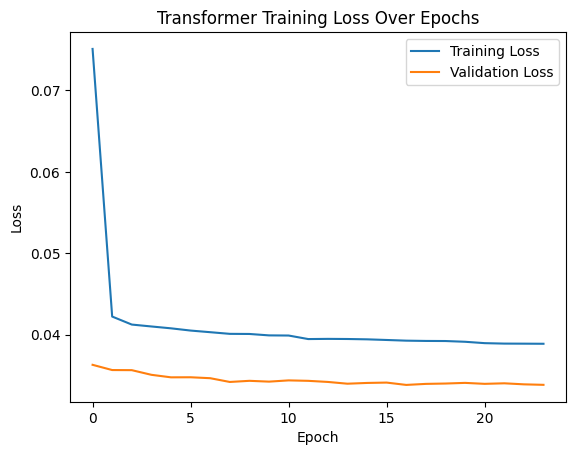

In [17]:
plt.plot(hist.history["loss"], label="Training Loss")
plt.plot(hist.history["val_loss"], label="Validation Loss")
plt.title("Transformer Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [18]:
pred = model.predict(x_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

822/822 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
MAE: 0.033647317431917706
RMSE: 0.049479672204130416
R²: 0.5233157345890316


In [19]:
import plotly.graph_objects as go


y_test_pred_rescaled = scaler_y.inverse_transform(pred)
y_test_true_rescaled = scaler_y.inverse_transform(y_test)

test_start_idx = split + lookback
pm25_raw = air_qual["pm2_5 (μg/m³)"].values

# Timeline Arrays for X-axis positioning
history_x = list(range(lookback))
forecast_x = list(range(lookback, lookback + forecast_steps))

fig = go.Figure()

sample_idx = 0
global_start = test_start_idx + sample_idx

fig.add_trace(go.Scatter(
    x=history_x, 
    y=pm25_raw[global_start - lookback : global_start],
    mode='lines+markers', name='Historical PM2.5', line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=forecast_x, 
    y=y_test_true_rescaled[sample_idx],
    mode='lines+markers', name='Actual Future', line=dict(color='green', dash='dash')
))

fig.add_trace(go.Scatter(
    x=forecast_x, 
    y=y_test_pred_rescaled[sample_idx],
    mode='lines+markers', name='Predicted Forecast', line=dict(color='red')
))

# 2. Build the dropdown menus for the first 50 test samples
num_samples_to_show = min(50, len(x_test))
buttons = []

for idx in range(num_samples_to_show):
    visibility = [False] * (num_samples_to_show * 3)
    visibility[idx * 3] = True
    visibility[idx * 3 + 1] = True
    visibility[idx * 3 + 2] = True
    
    button = dict(
        label=f"Sample {idx}",
        method="update",
        args=[
            {"visible": visibility},
            {"title": f"PM2.5 Timeline: 24h History + 5-Step Forecast (Sample {idx})"}
        ]
    )
    buttons.append(button)

# 3. Generate all remaining hidden traces for the selector upfront
for idx in range(1, num_samples_to_show):
    g_start = test_start_idx + idx
    fig.add_trace(go.Scatter(
        x=history_x, y=pm25_raw[g_start - lookback : g_start],
        mode='lines+markers', name='Historical PM2.5', line=dict(color='blue'), visible=False
    ))
    # Actual
    fig.add_trace(go.Scatter(
        x=forecast_x, y=y_test_true_rescaled[idx],
        mode='lines+markers', name='Actual Future', line=dict(color='green', dash='dash'), visible=False
    ))
    # Predicted
    fig.add_trace(go.Scatter(
        x=forecast_x, y=y_test_pred_rescaled[idx],
        mode='lines+markers', name='Predicted Forecast', line=dict(color='red'), visible=False
    ))

# 4. Final Layout Customization
fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, direction="down", pad={"r": 10, "t": 10}, showactive=True, x=0.02, xanchor="left", y=1.15, yanchor="top")],
    title="PM2.5 Timeline: 24h History + 5-Step Forecast (Sample 0)",
    xaxis_title="Timeline (Hours)",
    yaxis_title="PM2.5 Concentration (μg/m³)",
    height=600,
    showlegend=True
)

fig.add_vline(x=23.5, line_width=2, line_dash="dash", line_color="gray")

fig.show()

# trasnformer

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, MultiHeadAttention, LayerNormalization, Conv1D, GlobalAveragePooling1D
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 1. Data Preprocessing (Preserved)
# ==========================================
features_df = dataset.drop(columns=["pm2_5 (μg/m³)"])
target_df = dataset[["pm2_5 (μg/m³)"]]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaled_X = scaler_X.fit_transform(features_df)
scaled_y = scaler_y.fit_transform(target_df)

lookback = 24 * 5
forecast_steps = 24 

x = []
y = []
for i in range(lookback, len(dataset) - forecast_steps + 1):
    x.append(scaled_X[i-lookback:i, :])
    y.append(scaled_y[i:i+forecast_steps, 0])

x = np.array(x)
y = np.array(y)

split = int(len(x) * 0.7)
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, MultiHeadAttention, LayerNormalization, Conv1D, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping


class SinusoidalPositionalEncoding(tf.keras.layers.Layer):
    """Computes fixed, deterministic sine/cosine positional encodings."""
    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        position = np.arange(sequence_length)[:, np.newaxis]
        div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
        
        pe = np.zeros((sequence_length, d_model))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        
        self.pe = tf.constant(pe, dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pe


def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.3):
    # Attention Block
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = Dropout(dropout)(x)
    res = x + inputs

    # Feed Forward Block
    x = LayerNormalization(epsilon=1e-6)(res)
    x = Conv1D(filters=ff_dim, kernel_size=1, activation="relu", kernel_regularizer="l2")(x)
    x = Dropout(dropout)(x)
    x = Conv1D(filters=inputs.shape[-1], kernel_size=1, kernel_regularizer="l2")(x)
    x = Dropout(dropout)(x)
    
    return x + res

seq_len = x_train.shape[1]
num_features = x_train.shape[2]
d_model = 48

inputs = Input(shape=(seq_len, num_features))

x = Dense(d_model)(inputs)
x = SinusoidalPositionalEncoding(seq_len, d_model)(x)

x = transformer_encoder(x, head_size=32, num_heads=4, ff_dim=64, dropout=0.2)
x = transformer_encoder(x, head_size=32, num_heads=4, ff_dim=32, dropout=0.2)

x = GlobalAveragePooling1D()(x)

x = Dense(64, activation="relu", kernel_regularizer="l2")(x) 
x = Dropout(0.2)(x)

outputs = Dense(forecast_steps)(x)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer="adam", loss="mse")


model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 120, 16)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 120, 64)   │      1,088 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sinusoidal_positio… │ (None, 120, 64)   │          0 │ dense_3[0][0]     │
│ (SinusoidalPositio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 120, 64)   │        128 │ sinusoidal_posit… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 120, 64)   │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 120, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 120, 64)   │          0 │ dropout_7[0][0],  │
│                     │                   │            │ sinusoidal_posit… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 120, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 120, 64)   │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 120, 64)   │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 120, 64)   │      4,160 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 120, 64)   │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 120, 64)   │          0 │ dropout_9[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 120, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 120, 64)   │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 120, 64)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 120, 64)   │          0 │ dropout_11[0][0], │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 120, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 120, 64)   │      4,160 │ layer_normalizat

 Total params: 140,472 (548.72 KB)

 Trainable params: 140,472 (548.72 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = model.fit(
    x_train, y_train, 
    validation_data=(x_test, y_test), 
    epochs=35, 
    batch_size=32)

Epoch 1/35


2026-06-15 23:30:08.779872: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f42fc3a7310 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-15 23:30:08.779931: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX 6000 Ada Generation, Compute Capability 8.9
2026-06-15 23:30:08.779939: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA RTX 6000 Ada Generation, Compute Capability 8.9
2026-06-15 23:30:08.978906: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-15 23:30:11.020278: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full 

  59/1915 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4.6081   

I0000 00:00:1781562619.439771  299790 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1901/1915 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8743

2026-06-15 23:30:25.447764: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-15 23:30:25.447802: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-15 23:30:25.447845: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-15 23:30:25.447867: I external/l

1915/1915 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8696

2026-06-15 23:30:33.945108: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-15 23:30:34.347599: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_725', 100 bytes spill stores, 100 bytes spill loads

2026-06-15 23:30:37.049211: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-15 23:30:37.049248: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were f

1915/1915 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 0.2354 - val_loss: 0.0032
Epoch 2/35
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0041 - val_loss: 0.0036
Epoch 3/35
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0039 - val_loss: 0.0035
Epoch 4/35
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0038 - val_loss: 0.0045
Epoch 5/35
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0036 - val_loss: 0.0043
Epoch 6/35
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0036 - val_loss: 0.0049
Epoch 7/35
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0034 - val_loss: 0.0040
Epoch 8/35
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0034 - val_loss: 0.0043
Epoch 9/35
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0033 - val_loss: 0.0050
Epoch 10/35
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0032 - val_loss: 0.0044
Epoch 11/35
1915/1915 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0032 - val_loss: 0.0043
Epoch 12/35
1915/1915 ━━━━━━━━━━━━━━━━━

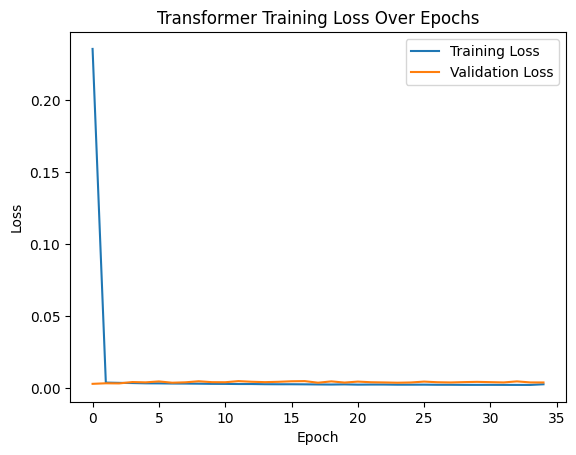

In [ ]:
plt.plot(hist.history["loss"], label="Training Loss")
plt.plot(hist.history["val_loss"], label="Validation Loss")
plt.title("Transformer Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
pred = model.predict(x_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

821/821 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
MAE: 0.0400963321539848
RMSE: 0.0624825791209093
R²: 0.2403370907999962


In [ ]:
# ==========================================
# 5. Interactive Visualization
# ==========================================
y_test_pred_rescaled = scaler_y.inverse_transform(pred)
y_test_true_rescaled = scaler_y.inverse_transform(y_test)

test_start_idx = split + lookback
pm25_raw = air_qual["pm2_5 (μg/m³)"].values

history_x = list(range(lookback))
forecast_x = list(range(lookback, lookback + forecast_steps))

fig = go.Figure()

sample_idx = 0
global_start = test_start_idx + sample_idx

fig.add_trace(go.Scatter(
    x=history_x, 
    y=pm25_raw[global_start - lookback : global_start],
    mode='lines+markers', name='Historical PM2.5', line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=forecast_x, 
    y=y_test_true_rescaled[sample_idx],
    mode='lines+markers', name='Actual Future', line=dict(color='green', dash='dash')
))

fig.add_trace(go.Scatter(
    x=forecast_x, 
    y=y_test_pred_rescaled[sample_idx],
    mode='lines+markers', name='Predicted Forecast', line=dict(color='red')
))

num_samples_to_show = min(50, len(x_test))
buttons = []

for idx in range(num_samples_to_show):
    visibility = [False] * (num_samples_to_show * 3)
    visibility[idx * 3] = True
    visibility[idx * 3 + 1] = True
    visibility[idx * 3 + 2] = True
    
    button = dict(
        label=f"Sample {idx}",
        method="update",
        args=[
            {"visible": visibility},
            {"title": f"PM2.5 Timeline: {lookback}h History + {forecast_steps}h Forecast (Sample {idx})"}
        ]
    )
    buttons.append(button)

for idx in range(1, num_samples_to_show):
    g_start = test_start_idx + idx
    fig.add_trace(go.Scatter(
        x=history_x, y=pm25_raw[g_start - lookback : g_start],
        mode='lines+markers', name='Historical PM2.5', line=dict(color='blue'), visible=False
    ))
    fig.add_trace(go.Scatter(
        x=forecast_x, y=y_test_true_rescaled[idx],
        mode='lines+markers', name='Actual Future', line=dict(color='green', dash='dash'), visible=False
    ))
    fig.add_trace(go.Scatter(
        x=forecast_x, y=y_test_pred_rescaled[idx],
        mode='lines+markers', name='Predicted Forecast', line=dict(color='red'), visible=False
    ))

fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, direction="down", pad={"r": 10, "t": 10}, showactive=True, x=0.02, xanchor="left", y=1.15, yanchor="top")],
    title=f"PM2.5 Timeline: {lookback}h History + {forecast_steps}h Forecast (Sample 0)",
    xaxis_title="Timeline (Hours)",
    yaxis_title="PM2.5 Concentration (μg/m³)",
    height=600,
    showlegend=True
)

# Places the vertical split line cleanly right at the end of history
fig.add_vline(x=lookback - 0.5, line_width=2, line_dash="dash", line_color="gray")

fig.show()